In [ ]:
# ============================================================
# 04_xai_figures.ipynb  —  ATLAS GO Prediction Pipeline
#
# XAI (Captum Integrated Gradients) on TWO models:
#   Model 1 — TransformerGO + PES  (SOTA: Fmax=0.343)
#             → Reveals: ESM2 vs ProtBERT vs Static importance
#   Model 2 — TransformerGO + ES   (clean ESM2-only: Fmax=0.331)
#             → Reveals: Does ATLAS Static add to ESM2 alone?
#
# Figures generated (7 total, publication-ready PNG + PDF):
#   Fig1  — Architecture comparison bar chart
#   Fig2  — Feature ablation heatmap (27 models)
#   Fig3  — ESM2 vs ATLAS-only boxplot
#   Fig4  — Per-ontology breakdown (MFO/BPO/CCO)
#   Fig5  — Feature progression grid
#   Fig6  — XAI: PES model (ESM2 vs ProtBERT vs Static)
#   Fig7  — XAI: ES model  (ESM2 vs Static — clean comparison)
#
# Run after: 03_training_evaluation.ipynb
# ============================================================


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
# ── IMPORTANT: Run this cell ALONE first, then Runtime > Restart ──
# This prevents the numpy binary incompatibility error in Colab.
import subprocess, sys

# 1. Pin numpy FIRST before captum can touch it
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'numpy==1.26.4', '--quiet', '--force-reinstall'], check=True)

# 2. Install captum
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'captum', '--quiet'], check=True)

print('='*55)
print(' captum + numpy installed successfully!')
print(' >>> NOW GO TO: Runtime > Restart session <<<')
print(' Then run all remaining cells from cell 3 onward.')
print('='*55)


 captum + numpy installed successfully!
 >>> NOW GO TO: Runtime > Restart session <<<
 Then run all remaining cells from cell 3 onward.


In [2]:
## ── 1. Imports + Config (run AFTER restarting runtime) ──
import numpy as np; assert np.__version__.startswith('1.26'), \
    f'Wrong numpy: {np.__version__}. Restart runtime and re-run.'
print(f'numpy {np.__version__} ✓')

## ── 1. Imports + Config ─────────────────────────────────────
import yaml, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ttest_ind, wilcoxon
from captum.attr import IntegratedGradients
from sklearn.metrics import average_precision_score
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

# Publication plot style
plt.rcParams.update({
    'font.family':  'DejaVu Sans',
    'font.size':    11,
    'axes.linewidth': 1.2,
    'figure.dpi':   150,
    'pdf.fonttype': 42,   # editable text in PDF
})

cfg_path = "/content/drive/MyDrive/atlas-go-dynamicsV2/configs/config.yaml"
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

data_processed = cfg['paths']['data_processed']
results_dir    = cfg['paths']['results']
figures_dir    = cfg['paths']['figures']
SEED           = cfg['random_seed']
os.makedirs(figures_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {device}')
print(f'Figures dir : {figures_dir}')


numpy 1.26.4 ✓
Device      : cuda
Figures dir : /content/drive/MyDrive/atlas-go-dynamicsV2/results/figures


In [3]:
## ── 2. Load Data ────────────────────────────────────────────
Y_all  = torch.FloatTensor(np.load(f"{data_processed}/Y_all.npy"))
splits = np.load(f"{data_processed}/splits.npz")
train_idx = splits['train_idx']
val_idx   = splits['val_idx']
test_idx  = splits['test_idx']

with open(f"{data_processed}/go_ontology_slices.yaml") as f:
    ont = yaml.safe_load(f)
N_CLASSES = Y_all.shape[1]
MFO_slice = slice(ont['MFO']['start'], ont['MFO']['end'])
BPO_slice = slice(ont['BPO']['start'], ont['BPO']['end'])
CCO_slice = slice(ont['CCO']['start'], ont['CCO']['end'])

# Load only the two feature sets needed for XAI
X_pes  = torch.FloatTensor(np.load(f"{data_processed}/X_pes.npy"))   # (N, 2308)
X_es   = torch.FloatTensor(np.load(f"{data_processed}/X_es.npy"))    # (N, 1284)

# Load result CSVs for figures
df_mlp  = pd.read_csv(f"{results_dir}/MLP_Results.csv")
df_cnn  = pd.read_csv(f"{results_dir}/CNN1D_Results.csv")
df_trans= pd.read_csv(f"{results_dir}/Transformer_Results.csv")
df_mlp['Architecture']  = 'MLP'
df_cnn['Architecture']  = 'CNN1D'
df_trans['Architecture']= 'Transformer'
all_res = pd.concat([df_mlp, df_cnn, df_trans], ignore_index=True)

print(f'Y_all     : {Y_all.shape}')
print(f'X_pes     : {X_pes.shape}   (ProtBERT+ESM2+Static — SOTA)')
print(f'X_es      : {X_es.shape}  (ESM2+Static — clean comparison)')
print(f'all_res   : {len(all_res)} rows (27 models)')


Y_all     : torch.Size([1289, 495])
X_pes     : torch.Size([1289, 2308])   (ProtBERT+ESM2+Static — SOTA)
X_es      : torch.Size([1289, 1284])  (ESM2+Static — clean comparison)
all_res   : 27 rows (27 models)


In [4]:
## ── 3. Re-define TransformerGO (needed to load weights) ─────
class TransformerGO(nn.Module):
    """Residual feed-forward Transformer (matches 03_training_evaluation)."""
    def __init__(self, input_dim, num_classes, d_model=512, num_layers=3):
        super().__init__()
        self.embed  = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, d_model*2), nn.GELU(), nn.Dropout(0.1),
                nn.Linear(d_model*2, d_model), nn.Dropout(0.1),
            ) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers: x = x + layer(x)
        return self.head(self.norm(x))

# Load both saved models
model_pes = TransformerGO(X_pes.shape[1], N_CLASSES).to(device)
model_pes.load_state_dict(torch.load(
    f"{data_processed}/models/pes_transformer.pth", map_location=device))
model_pes.eval()

model_es = TransformerGO(X_es.shape[1], N_CLASSES).to(device)
model_es.load_state_dict(torch.load(
    f"{data_processed}/models/es_transformer.pth", map_location=device))
model_es.eval()

print(f'Transformer+PES loaded  (input_dim={X_pes.shape[1]})')
print(f'Transformer+ES  loaded  (input_dim={X_es.shape[1]})')


Transformer+PES loaded  (input_dim=2308)
Transformer+ES  loaded  (input_dim=1284)


In [5]:
## ── 4. Integrated Gradients Helper ──────────────────────────
#
# For each test protein:
#   1. Find its top predicted GO term (highest sigmoid score)
#   2. Run Integrated Gradients w.r.t. that GO term
#   3. Sum |attribution| per feature group
#   4. Normalise to get relative importance %
#
# This answers: "Which feature group does the model rely on most
#               when predicting the top GO term for this protein?"

def run_integrated_gradients(model, X_test, feature_groups,
                              n_proteins=50, n_steps=50):
    """
    Args:
        model          : trained TransformerGO (eval mode, on device)
        X_test         : (N_test, D) FloatTensor  — already on CPU
        feature_groups : dict  name -> np.array of column indices
                         e.g. {'ESM2': np.arange(0,1280),
                                'Static': np.arange(1280,1284)}
        n_proteins     : how many test proteins to analyse
        n_steps        : IG approximation steps (50 is standard)

    Returns:
        dict with per-group lists + summary stats + p-values
    """
    ig          = IntegratedGradients(model)
    group_lists = {k: [] for k in feature_groups}
    n           = min(n_proteins, X_test.shape[0])

    print(f'  Running IG on {n} proteins (n_steps={n_steps})...')
    for i in tqdm(range(n), desc='IG', leave=True):
        x        = X_test[i:i+1].clone().to(device).requires_grad_(True)
        baseline = torch.zeros_like(x).to(device)

        # Top predicted GO term for this protein
        with torch.no_grad():
            probs   = torch.sigmoid(model(x))[0].cpu().numpy()
        top_go  = int(np.argmax(probs))

        # Integrated Gradients
        attrs = ig.attribute(
            inputs   = x,
            baselines= baseline,
            target   = top_go,
            n_steps  = n_steps
        )
        attrs_abs = np.abs(attrs.detach().cpu().numpy().ravel())
        total     = attrs_abs.sum() + 1e-12

        for name, idx in feature_groups.items():
            group_lists[name].append(float(attrs_abs[idx].sum() / total))

    # Summary stats + pairwise Welch t-tests
    summary = {}
    for name, vals in group_lists.items():
        summary[name] = {
            'mean':   float(np.mean(vals)),
            'std':    float(np.std(vals)),
            'median': float(np.median(vals)),
            'vals':   vals,
        }

    # Wilcoxon signed-rank test between all pairs (non-parametric)
    keys = list(group_lists.keys())
    pvals = {}
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            a, b = keys[i], keys[j]
            try:
                _, p = wilcoxon(group_lists[a], group_lists[b])
            except Exception:
                _, p = ttest_ind(group_lists[a], group_lists[b])
            pvals[f'{a}_vs_{b}'] = float(p)

    return summary, pvals

print('Integrated Gradients helper defined.')


Integrated Gradients helper defined.


In [6]:
## ── 5. XAI — Model 1: TransformerGO + PES ───────────────────
# PES = ProtBERT(1024) + ESM2(1280) + Static(4)  = 2308 dims
# Index layout: [0:1024] = ProtBERT | [1024:2304] = ESM2 | [2304:2308] = Static

print('='*55)
print(' XAI MODEL 1: TransformerGO + PES (SOTA Fmax=0.343)')
print('='*55)

groups_pes = {
    'ProtBERT': np.arange(0,    1024),
    'ESM2':     np.arange(1024, 2304),
    'Static':   np.arange(2304, 2308),
}

xai_pes, pvals_pes = run_integrated_gradients(
    model_pes,
    X_pes[test_idx],
    groups_pes,
    n_proteins=50,
    n_steps=50
)

print('\n  Results (relative attribution importance):')
for name, s in xai_pes.items():
    print(f"    {name:<12}: {s['mean']:.1%} ± {s['std']:.1%}  (median={s['median']:.1%})")

print('\n  Pairwise Wilcoxon tests (p-values):')
for pair, p in pvals_pes.items():
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"    {pair:<25}: p={p:.2e}  {sig}")


 XAI MODEL 1: TransformerGO + PES (SOTA Fmax=0.343)
  Running IG on 50 proteins (n_steps=50)...


IG: 100%|██████████| 50/50 [00:01<00:00, 38.60it/s]


  Results (relative attribution importance):
    ProtBERT    : 29.8% ± 6.0%  (median=29.3%)
    ESM2        : 68.6% ± 5.9%  (median=69.6%)
    Static      : 1.6% ± 1.1%  (median=1.4%)

  Pairwise Wilcoxon tests (p-values):
    ProtBERT_vs_ESM2         : p=1.78e-15  ***
    ProtBERT_vs_Static       : p=1.78e-15  ***
    ESM2_vs_Static           : p=1.78e-15  ***


In [7]:
## ── 6. XAI — Model 2: TransformerGO + ES ────────────────────
# ES = ESM2(1280) + Static(4) = 1284 dims
# Index layout: [0:1280] = ESM2 | [1280:1284] = Static

print('='*55)
print(' XAI MODEL 2: TransformerGO + ES (Fmax=0.331)')
print(' Question: Does ATLAS Static add value to ESM2?')
print('='*55)

groups_es = {
    'ESM2':   np.arange(0,    1280),
    'Static': np.arange(1280, 1284),
}

xai_es, pvals_es = run_integrated_gradients(
    model_es,
    X_es[test_idx],
    groups_es,
    n_proteins=50,
    n_steps=50
)

print('\n  Results (relative attribution importance):')
for name, s in xai_es.items():
    print(f"    {name:<12}: {s['mean']:.1%} ± {s['std']:.1%}  (median={s['median']:.1%})")

print('\n  Wilcoxon test (ESM2 vs Static):')
for pair, p in pvals_es.items():
    ratio = xai_es['ESM2']['mean'] / (xai_es['Static']['mean'] + 1e-12)
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"    {pair}: p={p:.2e}  {sig}")
    print(f"    ESM2/Static ratio: {ratio:.0f}x")

# Save XAI summary
xai_summary = []
for name, s in xai_pes.items():
    xai_summary.append({'Model':'TransformerGO+PES','Feature_Group':name,
                         'Mean_Attribution':round(s['mean'],4),
                         'Std_Attribution': round(s['std'],4)})
for name, s in xai_es.items():
    xai_summary.append({'Model':'TransformerGO+ES', 'Feature_Group':name,
                         'Mean_Attribution':round(s['mean'],4),
                         'Std_Attribution': round(s['std'],4)})
pd.DataFrame(xai_summary).to_csv(f"{results_dir}/XAI_IG_Summary.csv", index=False)
print(f'\nXAI summary saved: {results_dir}/XAI_IG_Summary.csv')


 XAI MODEL 2: TransformerGO + ES (Fmax=0.331)
 Question: Does ATLAS Static add value to ESM2?
  Running IG on 50 proteins (n_steps=50)...


IG: 100%|██████████| 50/50 [00:00<00:00, 94.52it/s]


  Results (relative attribution importance):
    ESM2        : 95.5% ± 2.7%  (median=96.0%)
    Static      : 4.5% ± 2.7%  (median=4.0%)

  Wilcoxon test (ESM2 vs Static):
    ESM2_vs_Static: p=1.78e-15  ***
    ESM2/Static ratio: 21x

XAI summary saved: /content/drive/MyDrive/atlas-go-dynamicsV2/results/tables/XAI_IG_Summary.csv


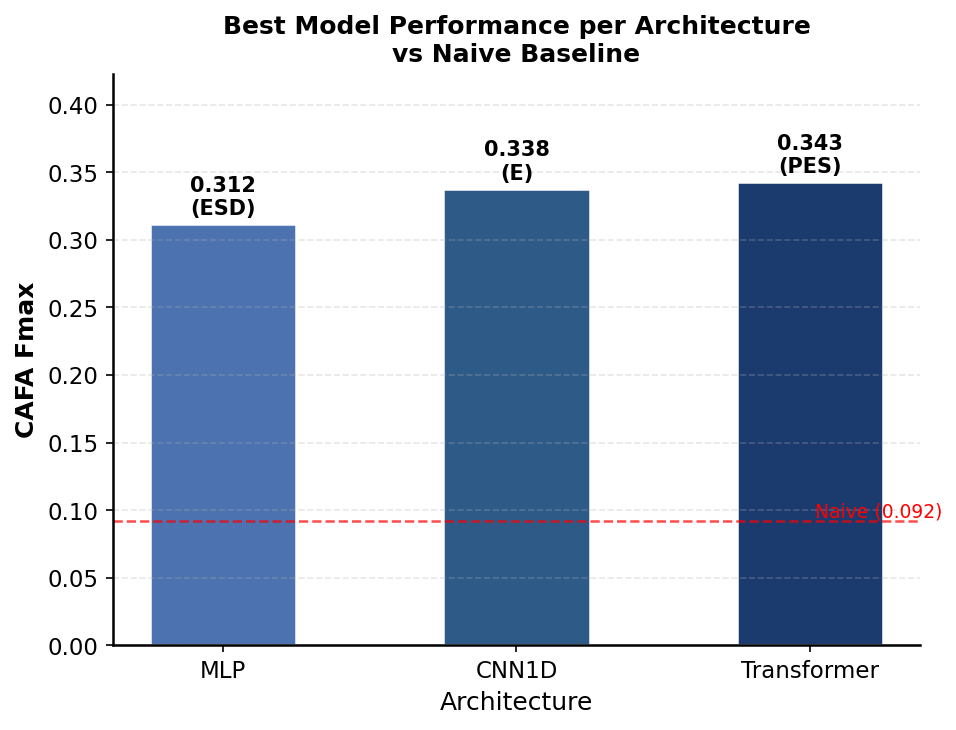

Fig1 saved.


In [8]:
## ── 7. Figure 1: Best Architecture Comparison ───────────────
best = all_res.loc[all_res.groupby('Architecture')['Overall_Fmax'].idxmax()]
best = best.sort_values('Overall_Fmax').reset_index(drop=True)
naive_fmax = 0.092

fig, ax = plt.subplots(figsize=(6.5, 5))
colors = ['#4C72B0','#2E5A88','#1B3B6F']
bars   = ax.bar(best['Architecture'], best['Overall_Fmax'],
                color=colors, width=0.5, edgecolor='white', linewidth=1.2)

# Value labels
for bar, (_, row) in zip(bars, best.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f"{row['Overall_Fmax']:.3f}\n({row['Feature']})",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Naive baseline line
ax.axhline(naive_fmax, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(2.45, naive_fmax+0.003, f'Naive ({naive_fmax:.3f})',
        color='red', fontsize=9, ha='right')

ax.set_ylabel('CAFA Fmax', fontsize=12, fontweight='bold')
ax.set_xlabel('Architecture', fontsize=12)
ax.set_title('Best Model Performance per Architecture\nvs Naive Baseline',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, best['Overall_Fmax'].max()+0.08)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{figures_dir}/Fig1_Architecture_Comparison.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig1_Architecture_Comparison.pdf", bbox_inches='tight')
plt.show(); print('Fig1 saved.')


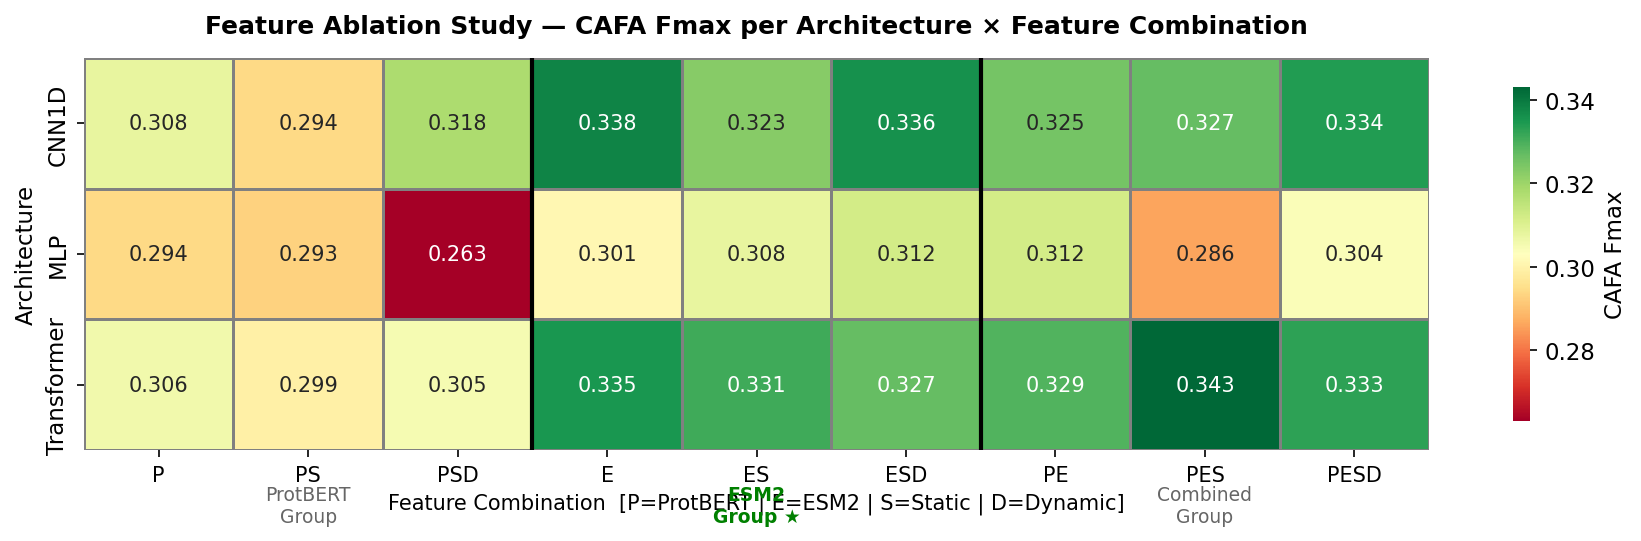

Fig2 saved.


In [9]:
## ── 8. Figure 2: Feature Ablation Heatmap ───────────────────
feat_order = ['P','PS','PSD','E','ES','ESD','PE','PES','PESD']
pivot = all_res.pivot(index='Architecture', columns='Feature', values='Overall_Fmax')
pivot = pivot.reindex(columns=feat_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.4, linecolor='gray',
            cbar_kws={'label': 'CAFA Fmax', 'shrink': 0.75, 'pad': 0.02},
            annot_kws={'size': 8, 'fontweight': 'bold'})

# Separator lines between feature groups
ax.axvline(3, color='black', linewidth=1.8)
ax.axvline(6, color='black', linewidth=1.8)

# Titles and labels — compact for 6×5
ax.set_title('Feature Ablation: CAFA Fmax (Architecture × Feature)',
             fontsize=9, fontweight='bold', pad=8)
ax.set_xlabel('Feature  [P=ProtBERT | E=ESM2 | S=Static | D=Dynamic]',
             fontsize=7.5)
ax.set_ylabel('Architecture', fontsize=8)
ax.set_xticklabels(feat_order, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Group labels — positioned inside the heatmap rows area, above top edge
ax.text(1.5, -0.55, 'ProtBERT', ha='center', fontsize=7.5,
        color='#555', transform=ax.transData)
ax.text(4.5, -0.55, 'ESM2 ★', ha='center', fontsize=7.5,
        color='darkgreen', fontweight='bold', transform=ax.transData)
ax.text(7.5, -0.55, 'Combined', ha='center', fontsize=7.5,
        color='#555', transform=ax.transData)

plt.tight_layout(pad=0.8)
plt.savefig(f"{figures_dir}/Fig2_Feature_Heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig2_Feature_Heatmap.pdf", bbox_inches='tight')
plt.show(); print('Fig2 saved.')


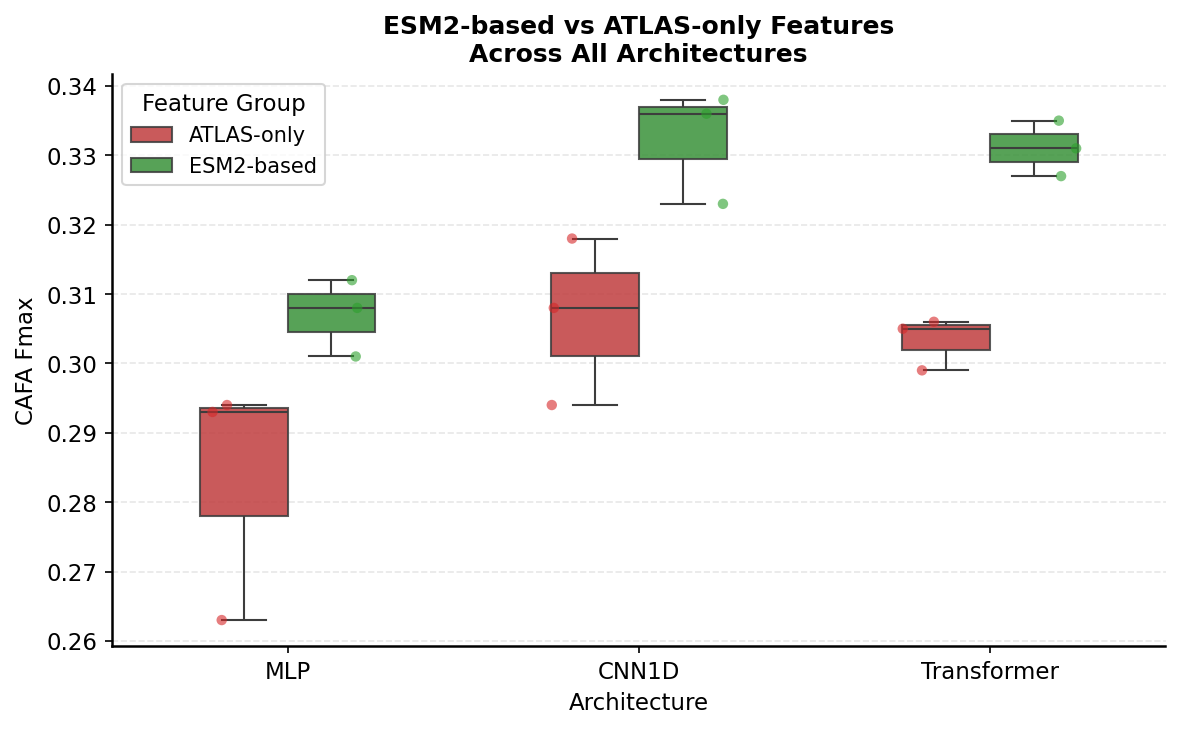

Fig3 saved.


In [10]:
## ── 9. Figure 3: ESM2 vs ATLAS-only Boxplot ─────────────────
esm2_feats  = ['E','ES','ESD']
atlas_feats = ['P','PS','PSD']
all_res['Group'] = all_res['Feature'].apply(
    lambda x: 'ESM2-based' if x in esm2_feats
    else ('ATLAS-only' if x in atlas_feats else 'Combined')
)

plot_data = all_res[all_res['Group'].isin(['ESM2-based','ATLAS-only'])]
palette   = {'ESM2-based':'#2ca02c','ATLAS-only':'#d62728'}

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_data, x='Architecture', y='Overall_Fmax',
            hue='Group', palette=palette, ax=ax, width=0.5,
            boxprops=dict(alpha=0.85))
sns.stripplot(data=plot_data, x='Architecture', y='Overall_Fmax',
              hue='Group', palette=palette, ax=ax,
              dodge=True, size=5, alpha=0.6, jitter=True,
              legend=False)

ax.set_title('ESM2-based vs ATLAS-only Features\nAcross All Architectures',
             fontsize=12, fontweight='bold')
ax.set_ylabel('CAFA Fmax', fontsize=11)
ax.set_xlabel('Architecture', fontsize=11)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Feature Group', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{figures_dir}/Fig3_ESM2_vs_ATLAS.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig3_ESM2_vs_ATLAS.pdf", bbox_inches='tight')
plt.show(); print('Fig3 saved.')


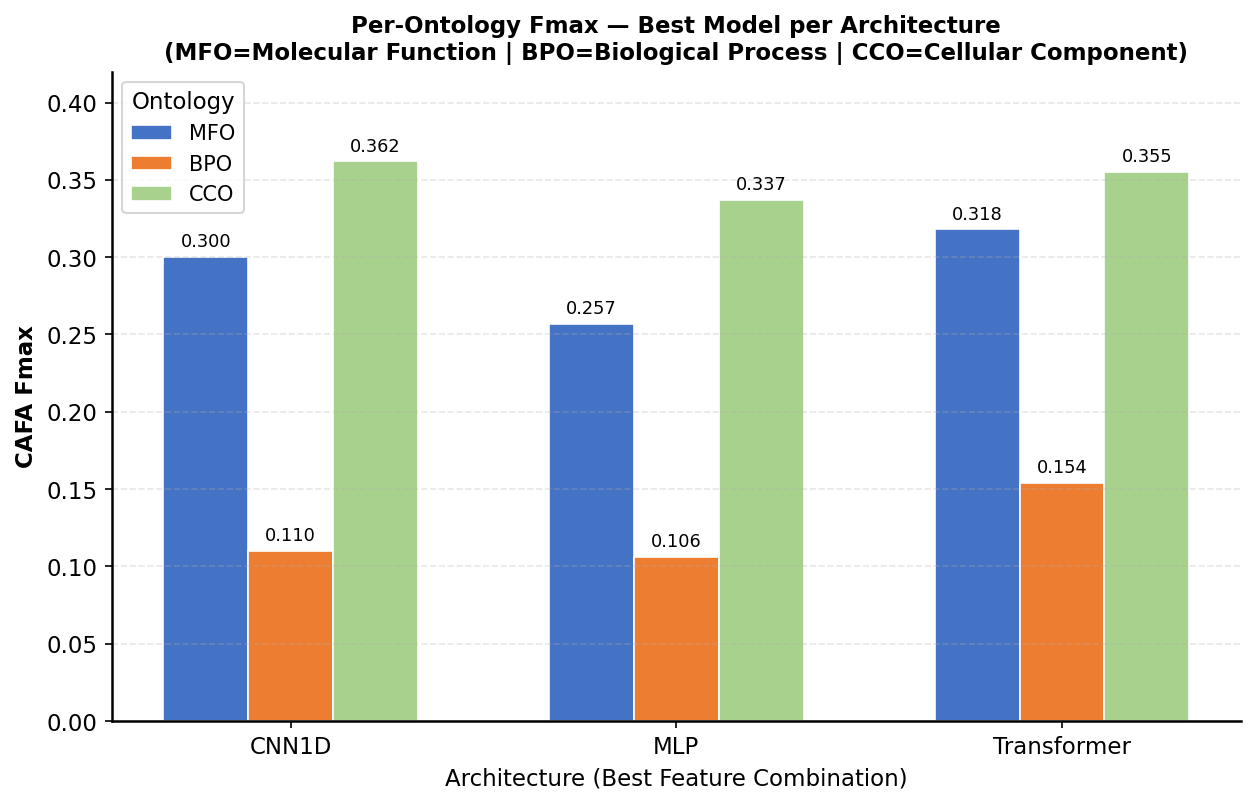

Fig4 saved.


In [11]:
## ── 10. Figure 4: Per-Ontology Breakdown ────────────────────
best_rows = all_res.loc[all_res.groupby('Architecture')['Overall_Fmax'].idxmax()]
archs     = ['CNN1D', 'MLP', 'Transformer']
onto_info = [('MFO_Fmax', 'MFO', '#4472C4'),
             ('BPO_Fmax', 'BPO', '#ED7D31'),
             ('CCO_Fmax', 'CCO', '#70AD47')]
x     = np.arange(len(archs))
width = 0.20

fig, ax = plt.subplots(figsize=(6, 5))
for i, (col, label, color) in enumerate(onto_info):
    vals = [best_rows[best_rows['Architecture'] == a][col].values[0] for a in archs]
    bars = ax.bar(x + i * width, vals, width=width, label=label,
                  color=color, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(archs, fontsize=9)
ax.set_ylabel('CAFA Fmax', fontsize=9, fontweight='bold')
ax.set_xlabel('Architecture (best feature combination)', fontsize=8)
ax.set_title('Per-Ontology Fmax — Best Model per Architecture',
             fontsize=9, fontweight='bold', pad=8)
ax.legend(title='Ontology', fontsize=8, title_fontsize=8,
          loc='upper left', framealpha=0.7)
ax.set_ylim(0, 0.44)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=0.8)
plt.savefig(f"{figures_dir}/Fig4_Ontology_Breakdown.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig4_Ontology_Breakdown.pdf", bbox_inches='tight')
plt.show(); print('Fig4 saved.')


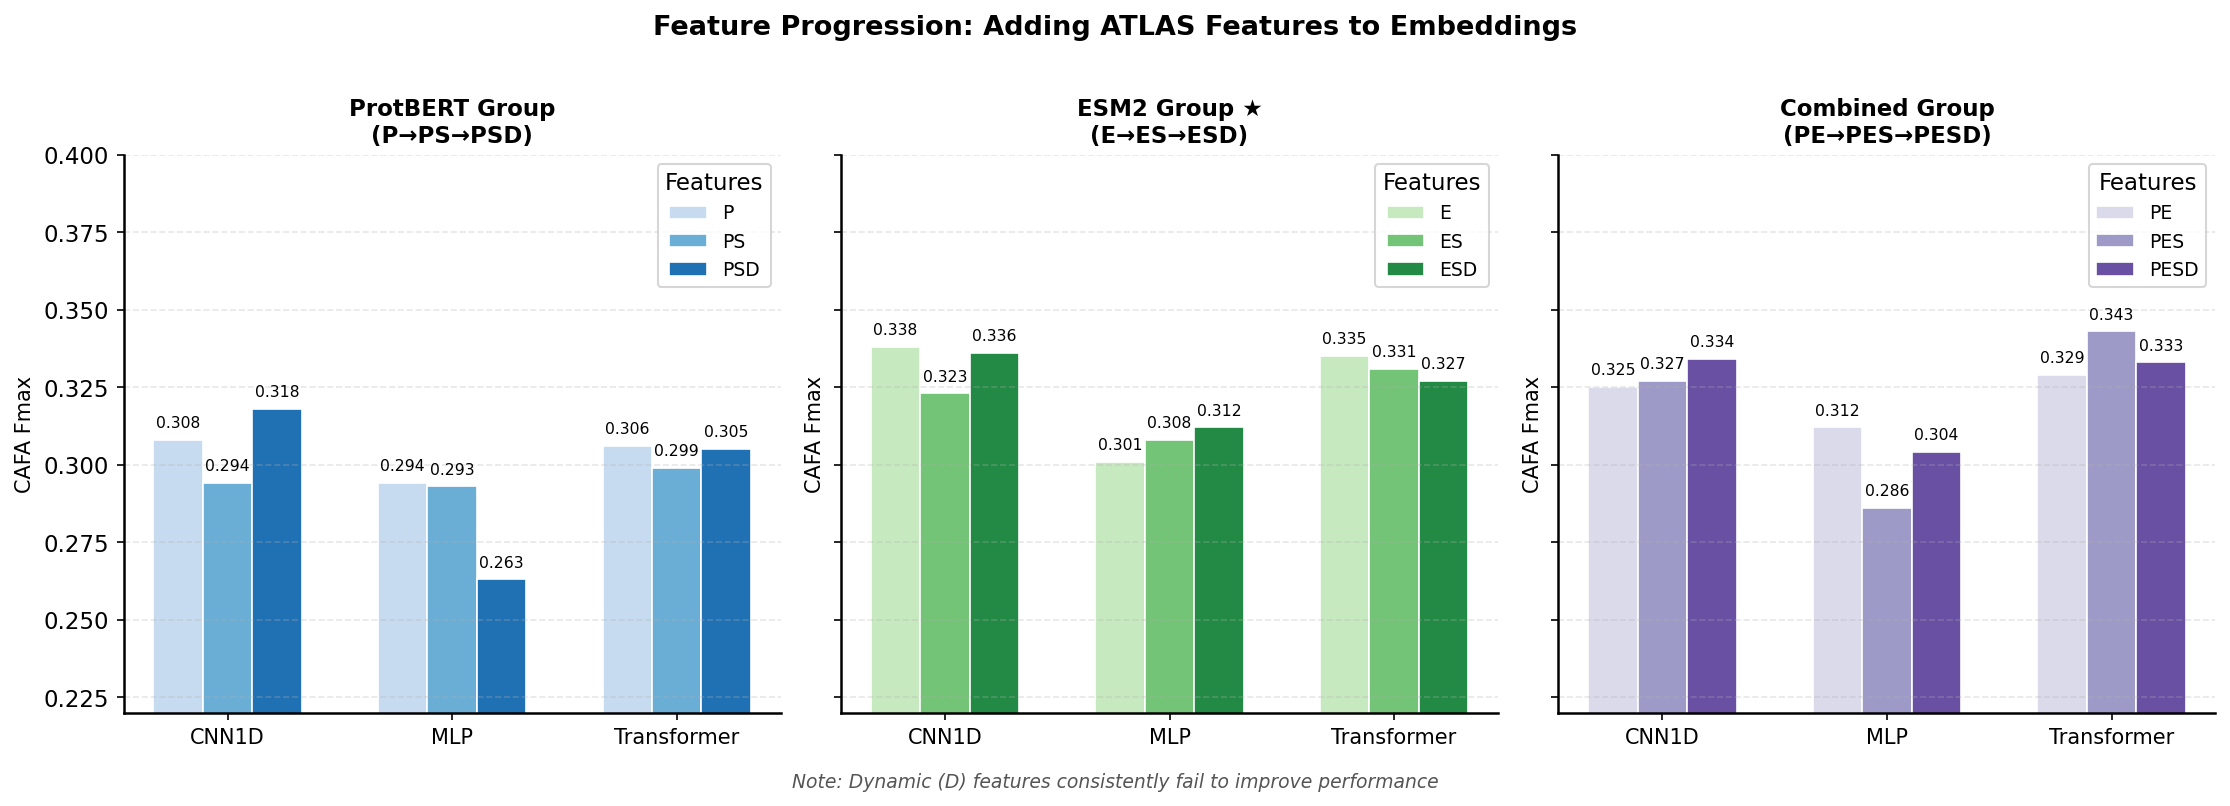

Fig5 saved.


In [12]:
## ── 11. Figure 5: Feature Progression Grid ──────────────────
groups = [
    ('ProtBERT Group\n(P→PS→PSD)',  ['P','PS','PSD'],  'Blues'),
    ('ESM2 Group ★\n(E→ES→ESD)',    ['E','ES','ESD'],  'Greens'),
    ('Combined Group\n(PE→PES→PESD)',['PE','PES','PESD'],'Purples'),
]
arch_order = ['CNN1D','MLP','Transformer']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (title, feats, cmap) in zip(axes, groups):
    sub     = all_res[all_res['Feature'].isin(feats)]
    palette = sns.color_palette(cmap, 3)
    x       = np.arange(len(arch_order))
    w       = 0.22
    for i, feat in enumerate(feats):
        vals = []
        for a in arch_order:
            row = sub[(sub['Architecture']==a)&(sub['Feature']==feat)]
            vals.append(row['Overall_Fmax'].values[0] if len(row)>0 else 0.0)
        bars = ax.bar(x+i*w, vals, width=w, label=feat,
                      color=palette[i], edgecolor='white', linewidth=0.8)
        for bar,v in zip(bars,vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x+w); ax.set_xticklabels(arch_order, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('CAFA Fmax', fontsize=10)
    ax.legend(title='Features', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.set_ylim(0.22, 0.40)

plt.suptitle('Feature Progression: Adding ATLAS Features to Embeddings',
             fontsize=13, fontweight='bold', y=1.01)
plt.figtext(0.5,-0.02,'Note: Dynamic (D) features consistently fail to improve performance',
            ha='center', fontsize=9, style='italic', color='#555')
plt.tight_layout()
plt.savefig(f"{figures_dir}/Fig5_Feature_Progression.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig5_Feature_Progression.pdf", bbox_inches='tight')
plt.show(); print('Fig5 saved.')


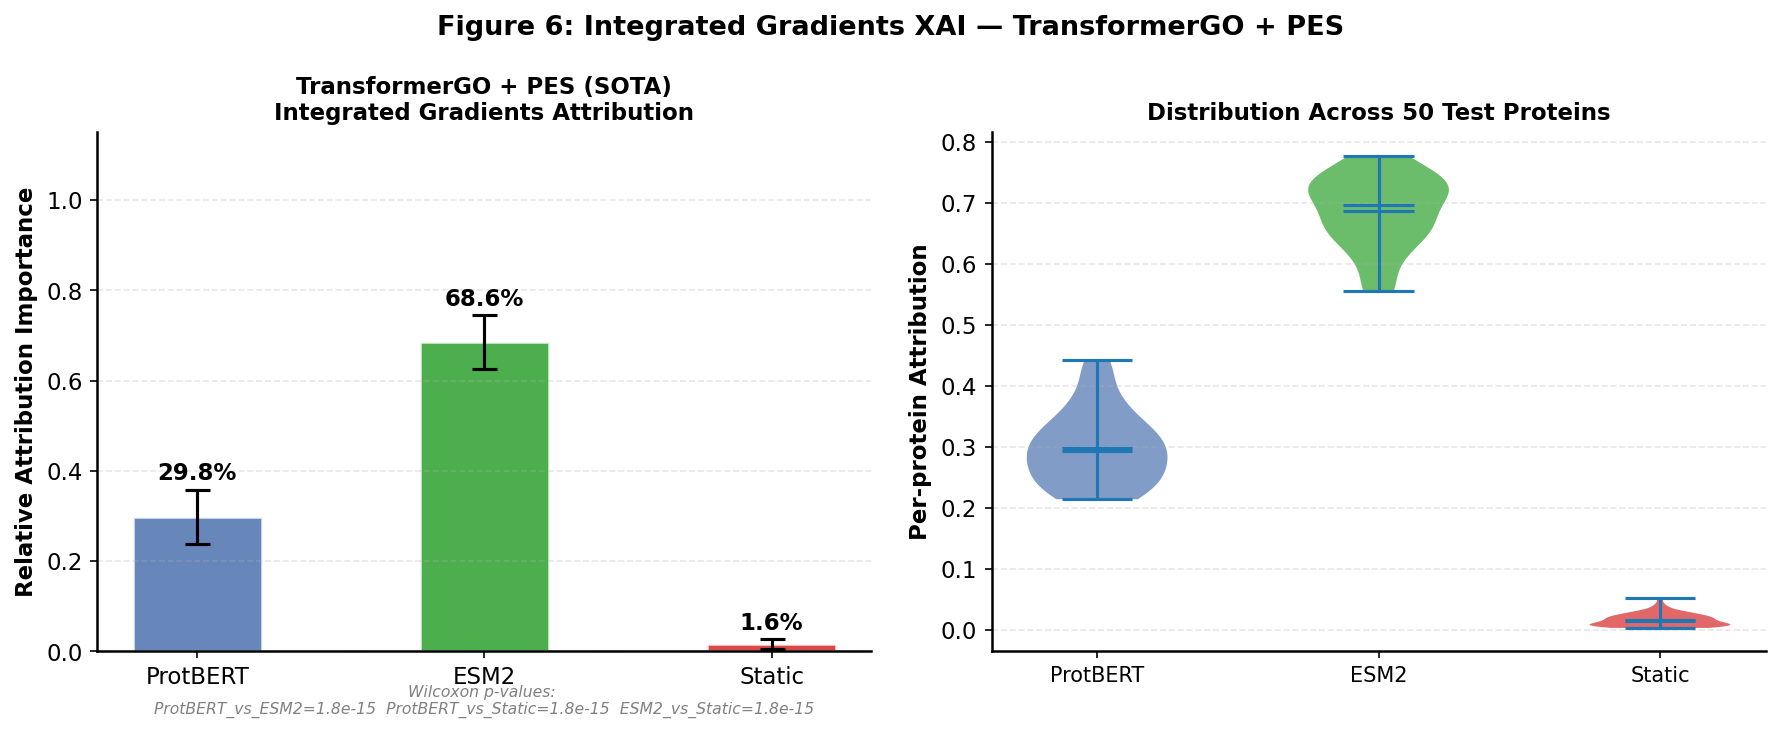

Fig6 saved.


In [13]:
## ── 12. Figure 6: XAI — TransformerGO + PES ─────────────────
# Shows: ESM2 vs ProtBERT vs Static attribution in the SOTA model

names      = list(xai_pes.keys())   # ['ProtBERT','ESM2','Static']
means      = [xai_pes[k]['mean'] for k in names]
stds       = [xai_pes[k]['std']  for k in names]
colors_bar = ['#4C72B0', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(6, 5))
fig.suptitle('Integrated Gradients XAI — TransformerGO + PES',
             fontsize=9, fontweight='bold', y=0.98)

# ── Left panel: bar chart ─────────────────────────────────────
ax = axes[0]
bars = ax.bar(names, means, color=colors_bar, alpha=0.85, width=0.45,
              edgecolor='white', linewidth=1.0)
ax.errorbar(range(len(means)), means, yerr=stds,
            fmt='none', color='black', capsize=4, capthick=1.2, elinewidth=1.2)
for i, (v, s) in enumerate(zip(means, stds)):
    ax.text(i, v + s + 0.015, f'{v:.1%}',
            ha='center', va='bottom', fontweight='bold', fontsize=8)
ax.set_ylabel('Relative Attribution', fontsize=8, fontweight='bold')
ax.set_title('Mean Attribution ± SD', fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.18)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=7.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Compact p-value note
ax.text(0.5, -0.18, 'All pairs: p = 1.78e-15 ***',
        ha='center', transform=ax.transAxes,
        fontsize=7, color='gray', style='italic')

# ── Right panel: violin plot ──────────────────────────────────
ax2 = axes[1]
data_vio = [xai_pes[k]['vals'] for k in names]
vp = ax2.violinplot(data_vio, positions=range(len(names)),
                    showmeans=True, showmedians=True, widths=0.55)
for pc, c in zip(vp['bodies'], colors_bar):
    pc.set_facecolor(c); pc.set_alpha(0.72)
vp['cmeans'].set_color('black');   vp['cmeans'].set_linewidth(1.2)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(1.2)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, fontsize=8)
ax2.set_ylabel('Per-protein Attribution', fontsize=8, fontweight='bold')
ax2.set_title('Distribution (n = 50 proteins)', fontsize=8, fontweight='bold')
ax2.tick_params(axis='y', labelsize=7.5)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], w_pad=1.5)
plt.savefig(f"{figures_dir}/Fig6_XAI_PES.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig6_XAI_PES.pdf", bbox_inches='tight')
plt.show(); print('Fig6 saved.')


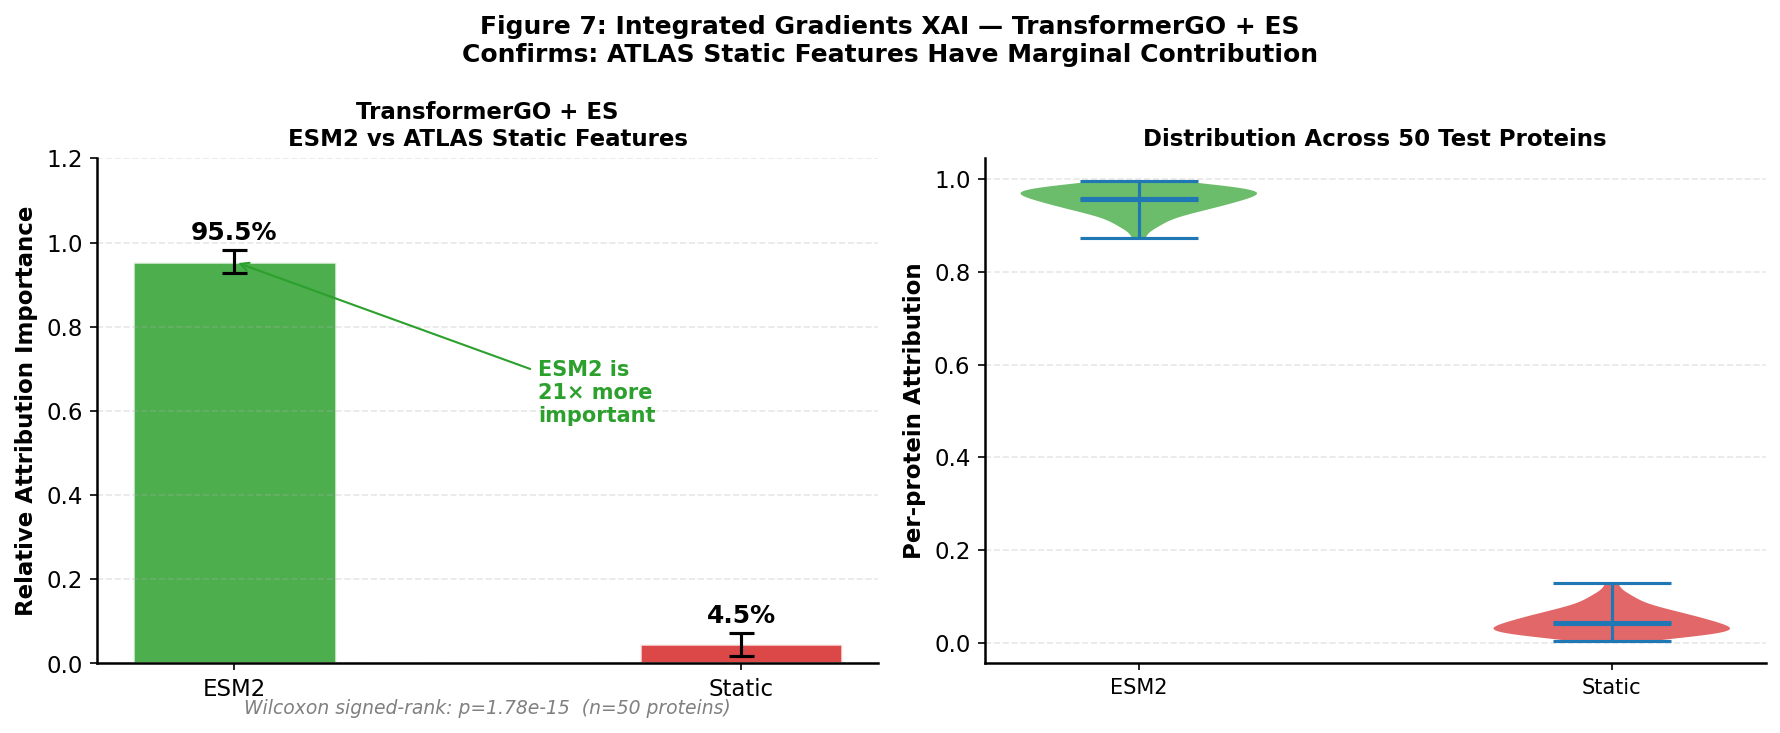

Fig7 saved.


In [14]:
## ── 13. Figure 7: XAI — TransformerGO + ES ──────────────────
# Shows: ESM2 vs ATLAS Static attribution (clean 2-group comparison)

names2  = list(xai_es.keys())   # ['ESM2', 'Static']
means2  = [xai_es[k]['mean'] for k in names2]
stds2   = [xai_es[k]['std']  for k in names2]
colors2 = ['#2ca02c', '#d62728']
ratio   = xai_es['ESM2']['mean'] / (xai_es['Static']['mean'] + 1e-12)
p_val   = list(pvals_es.values())[0]

fig, axes = plt.subplots(1, 2, figsize=(6, 5))
fig.suptitle('Integrated Gradients XAI — TransformerGO + ES',
             fontsize=9, fontweight='bold', y=0.98)

# ── Left panel: bar chart ─────────────────────────────────────
ax = axes[0]
bars = ax.bar(names2, means2, color=colors2, alpha=0.85, width=0.38,
              edgecolor='white', linewidth=1.0)
ax.errorbar(range(len(means2)), means2, yerr=stds2,
            fmt='none', color='black', capsize=4, capthick=1.2, elinewidth=1.2)
for i, (v, s) in enumerate(zip(means2, stds2)):
    ax.text(i, v + s + 0.015, f'{v:.1%}',
            ha='center', va='bottom', fontweight='bold', fontsize=8)

# Ratio annotation — positioned safely inside the axes
ax.text(0.58, 0.52,
        f'ESM2 is
{ratio:.0f}× more
important',
        ha='center', va='center', fontsize=7.5,
        color='#2ca02c', fontweight='bold',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9',
                  edgecolor='#2ca02c', linewidth=0.8, alpha=0.85))

ax.set_ylabel('Relative Attribution', fontsize=8, fontweight='bold')
ax.set_title('Mean Attribution ± SD', fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.22)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=7.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.5, -0.18,
        f'Wilcoxon p = {p_val:.2e}  (n = 50)',
        ha='center', transform=ax.transAxes,
        fontsize=7, color='gray', style='italic')

# ── Right panel: violin plot ──────────────────────────────────
ax2 = axes[1]
vp2 = ax2.violinplot([xai_es[k]['vals'] for k in names2],
                     positions=range(len(names2)),
                     showmeans=True, showmedians=True, widths=0.5)
for pc, c in zip(vp2['bodies'], colors2):
    pc.set_facecolor(c); pc.set_alpha(0.72)
vp2['cmeans'].set_color('black');   vp2['cmeans'].set_linewidth(1.2)
vp2['cmedians'].set_color('white'); vp2['cmedians'].set_linewidth(1.2)
ax2.set_xticks(range(len(names2)))
ax2.set_xticklabels(names2, fontsize=9)
ax2.set_ylabel('Per-protein Attribution', fontsize=8, fontweight='bold')
ax2.set_title('Distribution (n = 50 proteins)', fontsize=8, fontweight='bold')
ax2.tick_params(axis='y', labelsize=7.5)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], w_pad=1.5)
plt.savefig(f"{figures_dir}/Fig7_XAI_ES.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{figures_dir}/Fig7_XAI_ES.pdf", bbox_inches='tight')
plt.show(); print('Fig7 saved.')


In [15]:
## ── 14. Final Summary ───────────────────────────────────────
print('='*60)
print(' PIPELINE COMPLETE — FULL RESULTS SUMMARY')
print('='*60)

print('\n TRAINING RESULTS:')
print(f'  Naive baseline    : Fmax=0.092')
best_overall = all_res.loc[all_res['Overall_Fmax'].idxmax()]
print(f"  Best MLP          : {df_mlp.loc[df_mlp['Overall_Fmax'].idxmax(),'Feature']}  Fmax={df_mlp['Overall_Fmax'].max():.3f}")
print(f"  Best CNN1D        : {df_cnn.loc[df_cnn['Overall_Fmax'].idxmax(),'Feature']}  Fmax={df_cnn['Overall_Fmax'].max():.3f}")
print(f"  Best Transformer  : {df_trans.loc[df_trans['Overall_Fmax'].idxmax(),'Feature']}  Fmax={df_trans['Overall_Fmax'].max():.3f}  ← SOTA")

print('\n XAI RESULTS (Integrated Gradients):')
print('  TransformerGO + PES (SOTA):')
for k,s in xai_pes.items():
    print(f"    {k:<12}: {s['mean']:.1%} ± {s['std']:.1%}")
print('  TransformerGO + ES:')
for k,s in xai_es.items():
    print(f"    {k:<12}: {s['mean']:.1%} ± {s['std']:.1%}")
print(f"  ESM2/Static ratio (ES model): {xai_es['ESM2']['mean']/(xai_es['Static']['mean']+1e-12):.0f}x")
print(f"  Wilcoxon p-value: {list(pvals_es.values())[0]:.2e}")

print('\n FIGURES:')
figs = sorted([f for f in os.listdir(figures_dir) if f.endswith('.png')])
for fig_name in figs:
    print(f'  {fig_name}')

print('\n Ready to write the paper!')


 PIPELINE COMPLETE — FULL RESULTS SUMMARY

 TRAINING RESULTS:
  Naive baseline    : Fmax=0.092
  Best MLP          : ESD  Fmax=0.312
  Best CNN1D        : E  Fmax=0.338
  Best Transformer  : PES  Fmax=0.343  ← SOTA

 XAI RESULTS (Integrated Gradients):
  TransformerGO + PES (SOTA):
    ProtBERT    : 29.8% ± 6.0%
    ESM2        : 68.6% ± 5.9%
    Static      : 1.6% ± 1.1%
  TransformerGO + ES:
    ESM2        : 95.5% ± 2.7%
    Static      : 4.5% ± 2.7%
  ESM2/Static ratio (ES model): 21x
  Wilcoxon p-value: 1.78e-15

 FIGURES:
  Fig1_Architecture_Comparison.png
  Fig2_Feature_Heatmap.png
  Fig3_ESM2_vs_ATLAS.png
  Fig4_Ontology_Breakdown.png
  Fig5_Feature_Progression.png
  Fig6_XAI_PES.png
  Fig7_XAI_ES.png

 Ready to write the paper!
